In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../CSVs/time_series_60min_singleindex.csv")

In [3]:
print("========== BASIC DATA OVERVIEW ==========")

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Dataset Shape ---")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n--- Column Names ---")
print(df.columns.tolist())

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Numerical Columns ---")
print(df.select_dtypes(include="number").columns.tolist())

print("\n--- Categorical Columns ---")
print(df.select_dtypes(exclude="number").columns.tolist())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows ---")
print(df.duplicated().sum())

print("\n--- Unique Values ---")
print(df.nunique())

print("\n--- Numerical Summary ---")
print(df.describe())

print("\n--- Date Information ---")
date_columns = df.select_dtypes(include=["datetime"]).columns.tolist()

if date_columns:
    for col in date_columns:
        print(f"{col}:")
        print("Minimum:", df[col].min())
        print("Maximum:", df[col].max())
else:
    print("No datetime columns detected.")

print("\n========== EDA OVERVIEW COMPLETE ==========")

========== BASIC DATA OVERVIEW ==========

--- First 5 Rows ---
          utc_timestamp        cet_cest_timestamp  \
0  2014-12-31T23:00:00Z  2015-01-01T00:00:00+0100   
1  2015-01-01T00:00:00Z  2015-01-01T01:00:00+0100   
2  2015-01-01T01:00:00Z  2015-01-01T02:00:00+0100   
3  2015-01-01T02:00:00Z  2015-01-01T03:00:00+0100   
4  2015-01-01T03:00:00Z  2015-01-01T04:00:00+0100   

   AT_load_actual_entsoe_transparency  AT_load_forecast_entsoe_transparency  \
0                                 NaN                                   NaN   
1                              5946.0                                6701.0   
2                              5726.0                                6593.0   
3                              5347.0                                6482.0   
4                              5249.0                                6454.0   

   AT_price_day_ahead  AT_solar_generation_actual  \
0                 NaN                         NaN   
1                35.0               

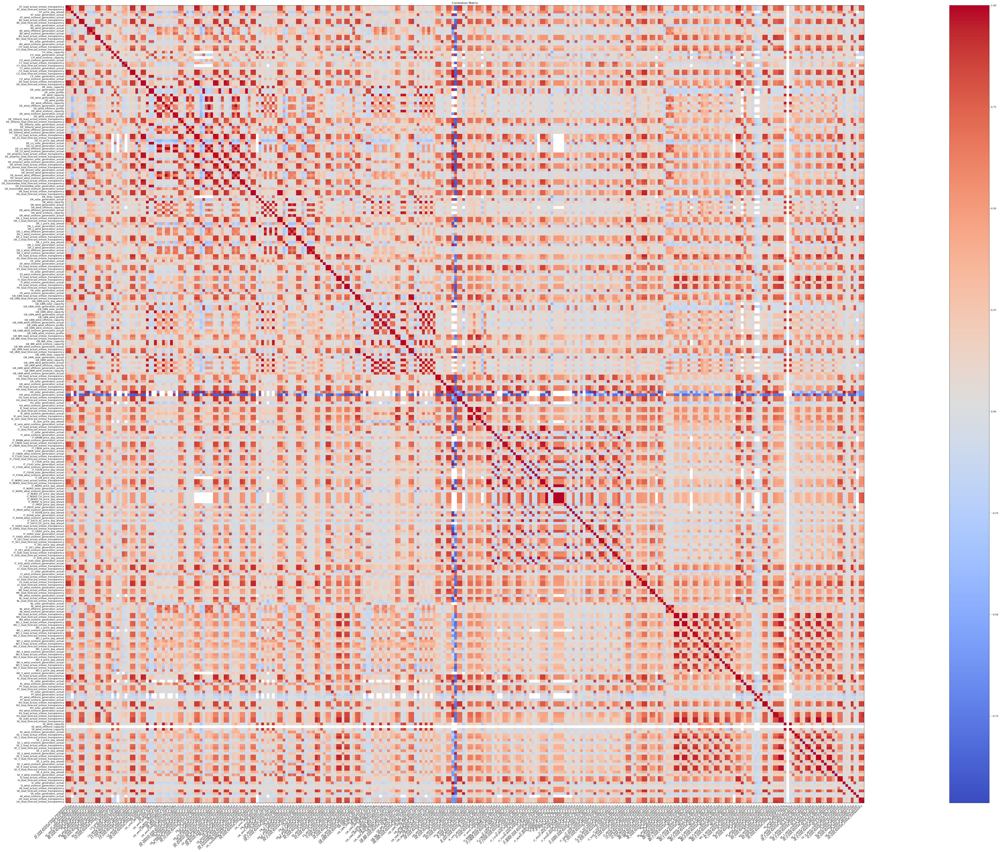

In [ ]:
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include="number")

if not numeric_df.empty:
    numeric_df.hist(figsize=(300, 100), bins=30, edgecolor="black")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(100, 50))
    plt.imshow(numeric_df.corr(), cmap="coolwarm")
    plt.colorbar()
    plt.title("Correlation Matrix")
    plt.xticks(range(len(numeric_df.columns)), numeric_df.columns, rotation=45, ha="right")
    plt.yticks(range(len(numeric_df.columns)), numeric_df.columns)
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns available for histogram/correlation plots.")

## EDA Findings

- The dataset contains 50,401 rows and 300 columns, representing an hourly time series with a large number of energy-related features.
- The dataset contains timestamp information together with electricity load, forecasts, solar generation, wind generation, capacity, and profile-related variables.
- Missing values are substantial, with 1,333,095 total null entries, indicating that missing-value handling or feature filtering will be necessary before modeling.
- The dataset contains no duplicate rows, indicating that the records are unique at the row level.
- The variables are largely numeric and structurally suitable for statistical and time-series analysis.
- The hourly resolution is appropriate for studying long-term trends, daily patterns, renewable-energy generation, electricity demand, and relationships among energy variables.
- Overall, the dataset is suitable for time-series EDA, correlation analysis, trend analysis, feature engineering, and predictive modeling after appropriate preprocessing.